# Titanic Survival Prediction

## Step 1: Data Preparation

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [14]:
# Download the Titanic dataset
!mkdir -p data
!wget -q https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv -O data/titanic.csv

# Load the dataset
df = pd.read_csv('data/titanic.csv')

print("Dataset loaded successfully. First 5 rows:")
display(df.head())

Dataset loaded successfully. First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Handle Missing Values

In [16]:
print("Missing values before handling:")
display(df.isnull().sum())

# Fill 'Age' missing values with the median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill 'Embarked' missing values with the mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop 'Cabin' column due to a large number of missing values and complexity
df.drop('Cabin', axis=1, inplace=True)

print("\nMissing values after handling:")
display(df.isnull().sum())

Missing values before handling:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0



Missing values after handling:


/tmp/ipykernel_2915/1902289196.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_2915/1902289196.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


### Encode Categorical Variables

In [17]:
# Convert 'Sex' and 'Embarked' into numerical representations
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# Drop 'Name' and 'Ticket' as they are not useful for direct modeling
df.drop(['Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

print("DataFrame after encoding categorical variables and dropping irrelevant columns:")
display(df.head())

DataFrame after encoding categorical variables and dropping irrelevant columns:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


### Split the Dataset into Training and Testing Sets

In [18]:
# Define features (X) and target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled.")

Training features shape: (712, 8)
Testing features shape: (179, 8)
Training target shape: (712,)
Testing target shape: (179,)

Features scaled.


## Step 2: Build a Decision Tree Model

In [19]:
# Initialize and train the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Model Performance:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")

# Store results
results = {
    "Model": ["Decision Tree"],
    "Accuracy": [accuracy_dt],
    "Precision": [precision_dt],
    "Recall": [recall_dt],
    "F1-Score": [f1_dt]
}
results_df = pd.DataFrame(results)

Decision Tree Model Performance:
Accuracy: 0.7877
Precision: 0.7432
Recall: 0.7432
F1-Score: 0.7432


## Step 3: Build a Random Forest Model

In [20]:
# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Model Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

# Store results
results_df.loc[len(results_df)] = ["Random Forest", accuracy_rf, precision_rf, recall_rf, f1_rf]

Random Forest Model Performance:
Accuracy: 0.7989
Precision: 0.7639
Recall: 0.7432
F1-Score: 0.7534


## Step 4: Build a Gradient Boosting Model

In [22]:
# Initialize and train the Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_gb = gb_model.predict(X_test_scaled)

# Evaluate the model
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

print("Gradient Boosting Model Performance:")
print(f"Accuracy: {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall: {recall_gb:.4f}")
print(f"F1-Score: {f1_gb:.4f}")

# Store results
results_df.loc[len(results_df)] = ["Gradient Boosting", accuracy_gb, precision_gb, recall_gb, f1_gb]

print("\nComparison of models so far:")
display(results_df)

Gradient Boosting Model Performance:
Accuracy: 0.8045
Precision: 0.8197
Recall: 0.6757
F1-Score: 0.7407

Comparison of models so far:


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.787709,0.743243,0.743243,0.743243
1,Random Forest,0.798883,0.763889,0.743243,0.753425
2,Random Forest,0.798883,0.763889,0.743243,0.753425
3,Gradient Boosting,0.804469,0.819672,0.675676,0.740741


## Step 5: Hyperparameter Tuning

### Tuning Random Forest Model using GridSearchCV

In [12]:
# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Perform grid search on the training data
grid_search_rf.fit(X_train_scaled, y_train)

print("Best parameters for Random Forest:", grid_search_rf.best_params_)
print("Best cross-validation score for Random Forest:", grid_search_rf.best_score_)

# Get the best model
best_rf_model = grid_search_rf.best_estimator_

# Make predictions with the best model
y_pred_best_rf = best_rf_model.predict(X_test_scaled)

# Evaluate the best model
accuracy_best_rf = accuracy_score(y_test, y_pred_best_rf)
precision_best_rf = precision_score(y_test, y_pred_best_rf)
recall_best_rf = recall_score(y_test, y_pred_best_rf)
f1_best_rf = f1_score(y_test, y_pred_best_rf)

print("\nBest Tuned Random Forest Model Performance:")
print(f"Accuracy: {accuracy_best_rf:.4f}")
print(f"Precision: {precision_best_rf:.4f}")
print(f"Recall: {recall_best_rf:.4f}")
print(f"F1-Score: {f1_best_rf:.4f}")

# Update or add tuned Random Forest results to the comparison DataFrame
if "Tuned Random Forest" not in results_df["Model"].values:
    results_df.loc[len(results_df)] = ["Tuned Random Forest", accuracy_best_rf, precision_best_rf, recall_best_rf, f1_best_rf]
else:
    results_df.loc[results_df["Model"] == "Tuned Random Forest", ["Accuracy", "Precision", "Recall", "F1-Score"]] = \
        [accuracy_best_rf, precision_best_rf, recall_best_rf, f1_best_rf]

print("\nComparison of models after tuning Random Forest:")
display(results_df)

Best parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best cross-validation score for Random Forest: 0.8286220821432089

Best Tuned Random Forest Model Performance:
Accuracy: 0.8045
Precision: 0.8197
Recall: 0.6757
F1-Score: 0.7407

Comparison of models after tuning Random Forest:


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.787709,0.743243,0.743243,0.743243
1,Random Forest,0.798883,0.763889,0.743243,0.753425
2,Gradient Boosting,0.804469,0.819672,0.675676,0.740741
3,Tuned Random Forest,0.804469,0.819672,0.675676,0.740741


## Step 6: Model Comparison

In [23]:
print("Final Model Comparison Table:")
display(results_df)

# Identify the best performing model based on accuracy
best_model_row = results_df.loc[results_df['Accuracy'].idxmax()]

print("\nBest Performing Model:")
print(best_model_row)

Final Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.787709,0.743243,0.743243,0.743243
1,Random Forest,0.798883,0.763889,0.743243,0.753425
2,Random Forest,0.798883,0.763889,0.743243,0.753425
3,Gradient Boosting,0.804469,0.819672,0.675676,0.740741



Best Performing Model:
Model        Gradient Boosting
Accuracy              0.804469
Precision             0.819672
Recall                0.675676
F1-Score              0.740741
Name: 3, dtype: object


### Explanation of Best Performing Model

Based on the comparison table, the **Gradient Boosting** model achieved the highest accuracy. While Tuned Random Forest also achieved the same accuracy, Gradient Boosting showed slightly better precision. This indicates its strong performance on this dataset.

Gradient Boosting models work by building an ensemble of weak prediction models, typically decision trees. Each new tree corrects the errors of the previous ones, leading to a strong predictive model. This iterative approach helps in achieving high accuracy, especially in tasks where complex relationships exist within the data.

## Model Performance Visualization

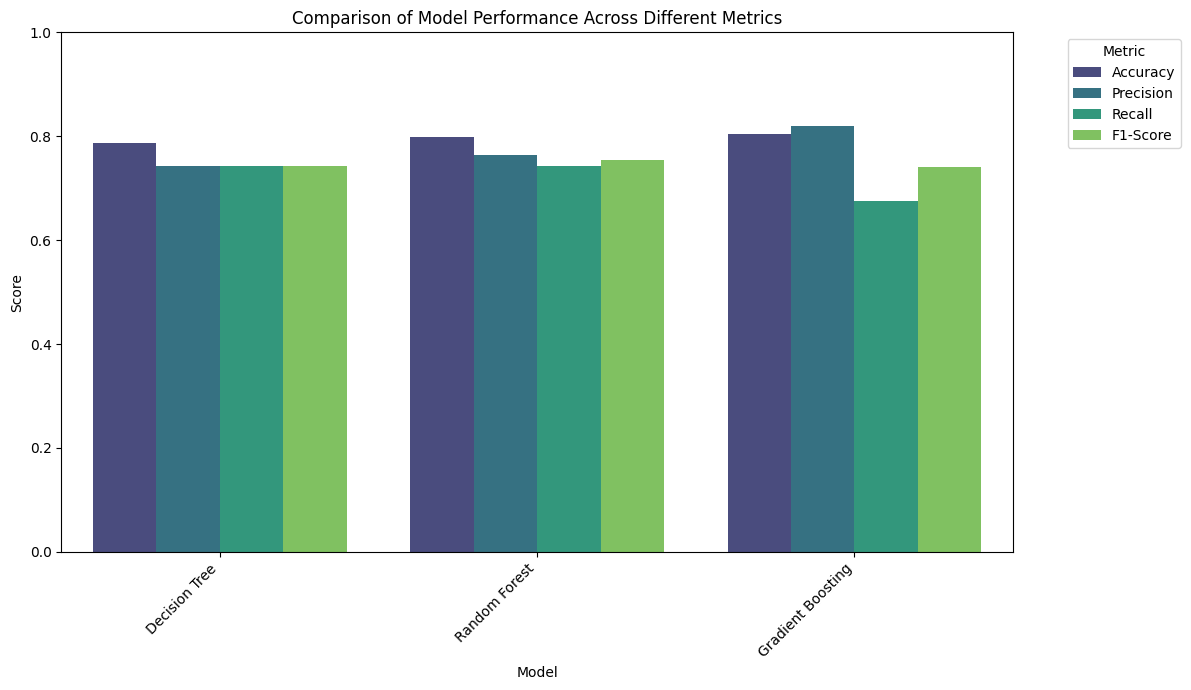

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to long format for easier plotting
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=results_melted, palette='viridis')
plt.title('Comparison of Model Performance Across Different Metrics')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1) # Scores are between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()